In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import classification_report, confusion_matrix, f1_score



import joblib


'''
The purpose of this program is to use the models previously trained on scenarios 1 and 2 
and test them on the rest of the scenarios.
'''

'\nThe purpose of this program is to use the models previously trained on scenarios 1 and 2 \nand test them on the rest of the scenarios.\n'

In [22]:

# Load the 3 models
rf = joblib.load('models/Random_Forest_1and2.joblib')
lgbm = joblib.load('models/LightGBM_1and2.joblib')
xgb = joblib.load('models/XGBoost_1and2.joblib')

In [23]:
#Function to clean label column
def extract_main_label(label):
    if 'Botnet' in label:
        return 'Botnet'
    elif 'Normal' in label:
        return 'Normal'
    elif 'Background' in label:
        return 'Background'
    return 'Unknown'


# Function to load each scenario into a dataframe, and clean up the features
def load_and_process(filepath):
    df = pd.read_csv(filepath)


    df['Label'] = df['Label'].apply(extract_main_label)
    df = df[df['Label'] != 'Unknown']

    # Drop features
    df = df.drop(columns=['StartTime', 'SrcAddr', 'DstAddr', 'Sport', 'Dport'])

    # Encode categorical features using LabelEncoder
    for col in df.select_dtypes(include='object').columns:
        if col != 'Label':
            df[col] = LabelEncoder().fit_transform(df[col])

    # Prepare features and labels
    X = df.drop(columns=['Label'])
    y = LabelEncoder().fit_transform(df['Label'])  # 0=Background, 1=Botnet, 2=Normal

    return X, y



--- Testing on datasets/scenario1.binetflow ---

=== Results for Random Forest ===
F1 Score (Macro Average): 0.4797

Confusion Matrix:


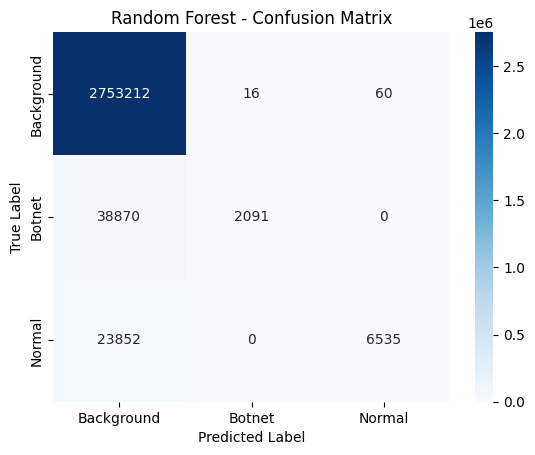


Classification Report:
 Background: Precision=0.98, Recall=1.00, F1-Score=0.99, Support=2753288
 Botnet: Precision=0.99, Recall=0.05, F1-Score=0.10, Support=40961
 Normal: Precision=0.99, Recall=0.22, F1-Score=0.35, Support=30387

 Macro Avg:
 Precision=0.99, Recall=0.42, F1-Score=0.48
--------------------------------------------------

=== Results for XGBoost ===
F1 Score (Macro Average): 0.5561

Confusion Matrix:


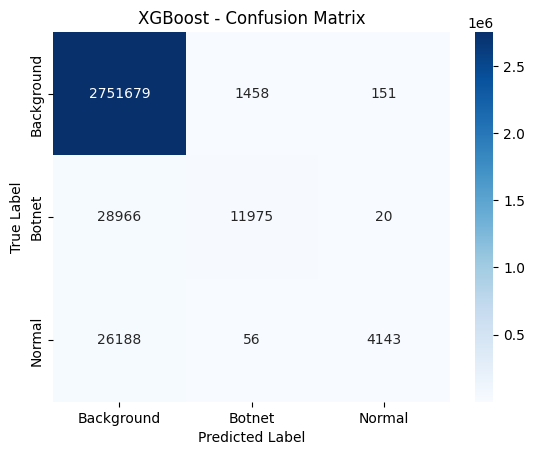


Classification Report:
 Background: Precision=0.98, Recall=1.00, F1-Score=0.99, Support=2753288
 Botnet: Precision=0.89, Recall=0.29, F1-Score=0.44, Support=40961
 Normal: Precision=0.96, Recall=0.14, F1-Score=0.24, Support=30387

 Macro Avg:
 Precision=0.94, Recall=0.48, F1-Score=0.56
--------------------------------------------------

=== Results for LightGBM ===
F1 Score (Macro Average): 0.6292

Confusion Matrix:


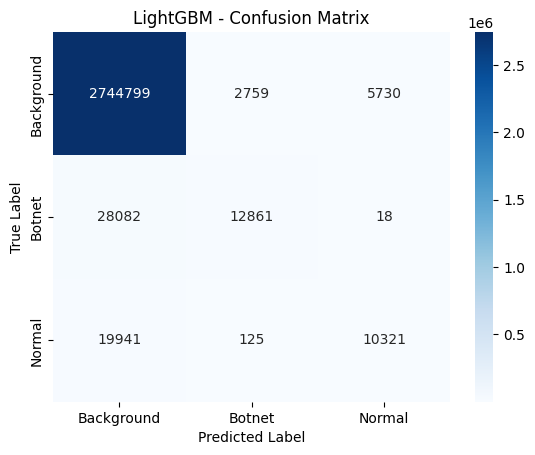


Classification Report:
 Background: Precision=0.98, Recall=1.00, F1-Score=0.99, Support=2753288
 Botnet: Precision=0.82, Recall=0.31, F1-Score=0.45, Support=40961
 Normal: Precision=0.64, Recall=0.34, F1-Score=0.44, Support=30387

 Macro Avg:
 Precision=0.81, Recall=0.55, F1-Score=0.63
--------------------------------------------------

--- Testing on datasets/scenario2.binetflow ---

=== Results for Random Forest ===
F1 Score (Macro Average): 0.6988

Confusion Matrix:


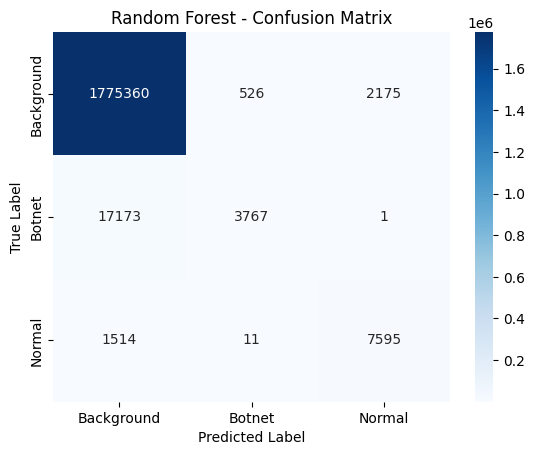


Classification Report:
 Background: Precision=0.99, Recall=1.00, F1-Score=0.99, Support=1778061
 Botnet: Precision=0.88, Recall=0.18, F1-Score=0.30, Support=20941
 Normal: Precision=0.78, Recall=0.83, F1-Score=0.80, Support=9120

 Macro Avg:
 Precision=0.88, Recall=0.67, F1-Score=0.70
--------------------------------------------------

=== Results for XGBoost ===
F1 Score (Macro Average): 0.6231

Confusion Matrix:


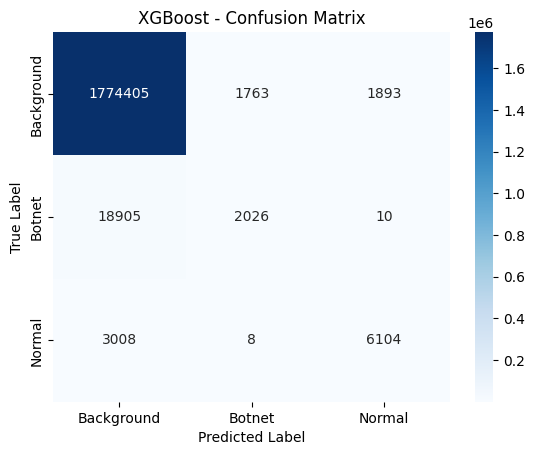


Classification Report:
 Background: Precision=0.99, Recall=1.00, F1-Score=0.99, Support=1778061
 Botnet: Precision=0.53, Recall=0.10, F1-Score=0.16, Support=20941
 Normal: Precision=0.76, Recall=0.67, F1-Score=0.71, Support=9120

 Macro Avg:
 Precision=0.76, Recall=0.59, F1-Score=0.62
--------------------------------------------------

=== Results for LightGBM ===
F1 Score (Macro Average): 0.6125

Confusion Matrix:


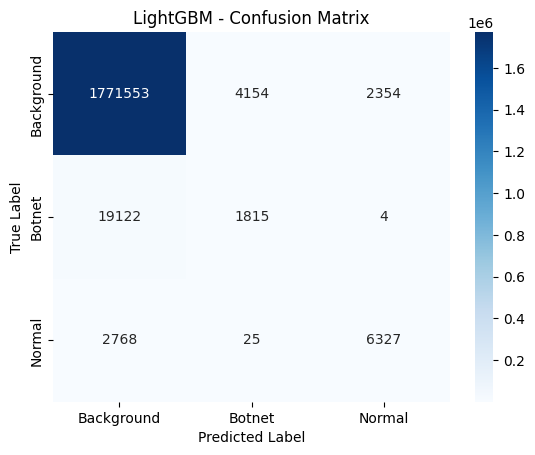


Classification Report:
 Background: Precision=0.99, Recall=1.00, F1-Score=0.99, Support=1778061
 Botnet: Precision=0.30, Recall=0.09, F1-Score=0.13, Support=20941
 Normal: Precision=0.73, Recall=0.69, F1-Score=0.71, Support=9120

 Macro Avg:
 Precision=0.67, Recall=0.59, F1-Score=0.61
--------------------------------------------------

--- Testing on datasets/scenario3.binetflow ---

=== Results for Random Forest ===
F1 Score (Macro Average): 0.5480

Confusion Matrix:


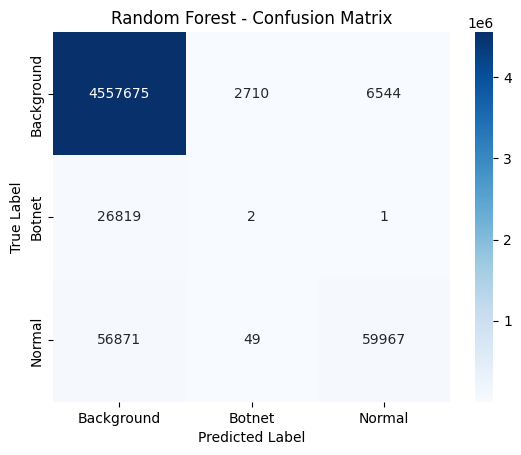


Classification Report:
 Background: Precision=0.98, Recall=1.00, F1-Score=0.99, Support=4566929
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=26822
 Normal: Precision=0.90, Recall=0.51, F1-Score=0.65, Support=116887

 Macro Avg:
 Precision=0.63, Recall=0.50, F1-Score=0.55
--------------------------------------------------

=== Results for XGBoost ===
F1 Score (Macro Average): 0.5643

Confusion Matrix:


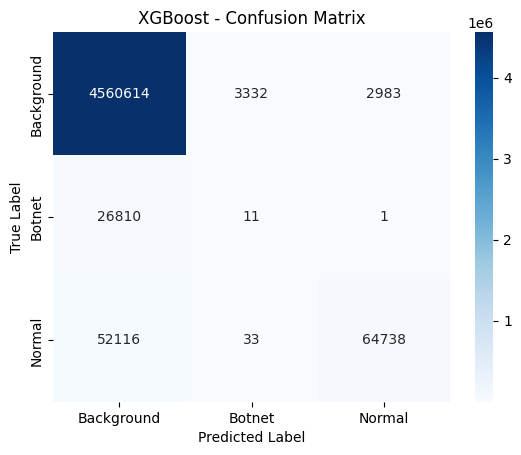


Classification Report:
 Background: Precision=0.98, Recall=1.00, F1-Score=0.99, Support=4566929
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=26822
 Normal: Precision=0.96, Recall=0.55, F1-Score=0.70, Support=116887

 Macro Avg:
 Precision=0.65, Recall=0.52, F1-Score=0.56
--------------------------------------------------

=== Results for LightGBM ===
F1 Score (Macro Average): 0.5641

Confusion Matrix:


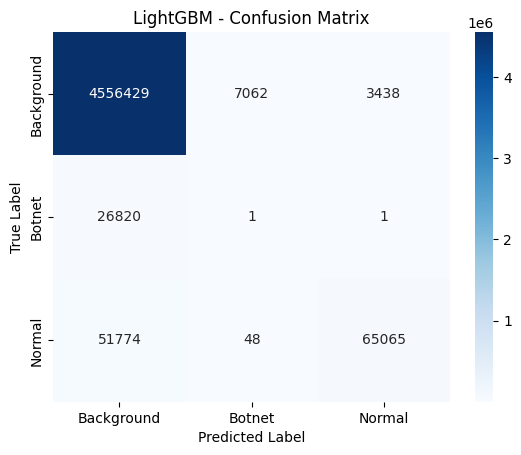


Classification Report:
 Background: Precision=0.98, Recall=1.00, F1-Score=0.99, Support=4566929
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=26822
 Normal: Precision=0.95, Recall=0.56, F1-Score=0.70, Support=116887

 Macro Avg:
 Precision=0.64, Recall=0.52, F1-Score=0.56
--------------------------------------------------

--- Testing on datasets/scenario4.binetflow ---

=== Results for Random Forest ===
F1 Score (Macro Average): 0.3959

Confusion Matrix:


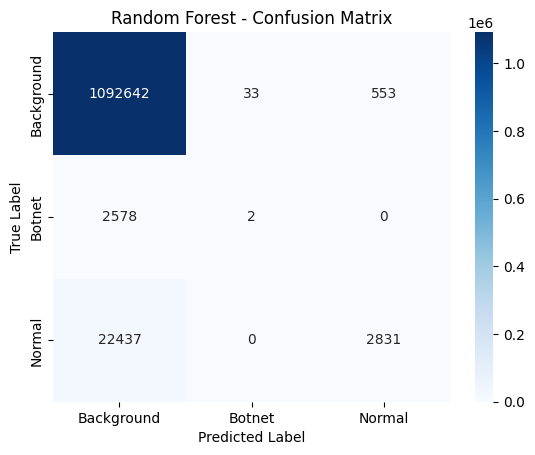


Classification Report:
 Background: Precision=0.98, Recall=1.00, F1-Score=0.99, Support=1093228
 Botnet: Precision=0.06, Recall=0.00, F1-Score=0.00, Support=2580
 Normal: Precision=0.84, Recall=0.11, F1-Score=0.20, Support=25268

 Macro Avg:
 Precision=0.62, Recall=0.37, F1-Score=0.40
--------------------------------------------------

=== Results for XGBoost ===
F1 Score (Macro Average): 0.3733

Confusion Matrix:


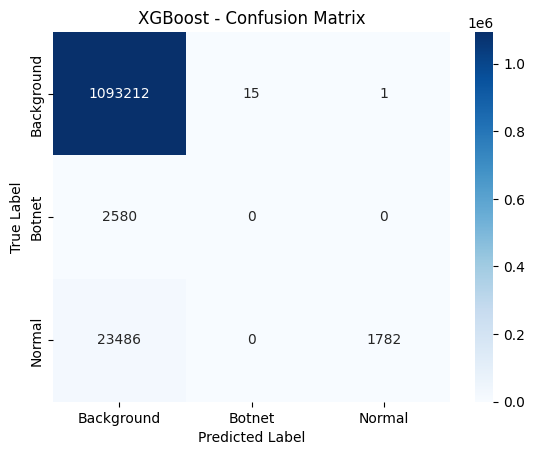


Classification Report:
 Background: Precision=0.98, Recall=1.00, F1-Score=0.99, Support=1093228
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=2580
 Normal: Precision=1.00, Recall=0.07, F1-Score=0.13, Support=25268

 Macro Avg:
 Precision=0.66, Recall=0.36, F1-Score=0.37
--------------------------------------------------

=== Results for LightGBM ===
F1 Score (Macro Average): 0.3829

Confusion Matrix:


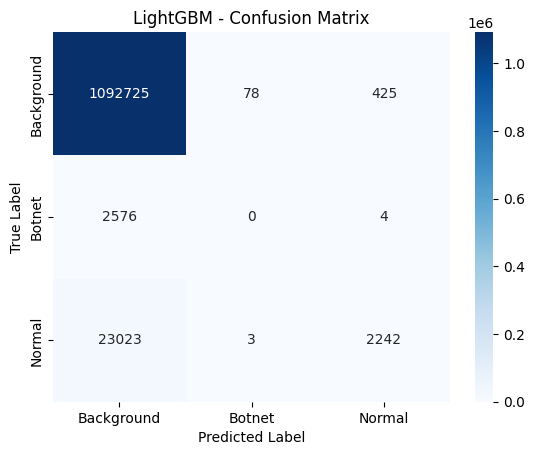


Classification Report:
 Background: Precision=0.98, Recall=1.00, F1-Score=0.99, Support=1093228
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=2580
 Normal: Precision=0.84, Recall=0.09, F1-Score=0.16, Support=25268

 Macro Avg:
 Precision=0.61, Recall=0.36, F1-Score=0.38
--------------------------------------------------

--- Testing on datasets/scenario5.binetflow ---

=== Results for Random Forest ===
F1 Score (Macro Average): 0.3580

Confusion Matrix:


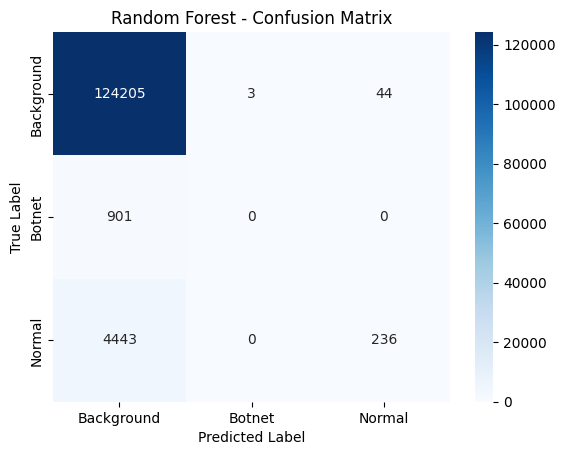


Classification Report:
 Background: Precision=0.96, Recall=1.00, F1-Score=0.98, Support=124252
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=901
 Normal: Precision=0.84, Recall=0.05, F1-Score=0.10, Support=4679

 Macro Avg:
 Precision=0.60, Recall=0.35, F1-Score=0.36
--------------------------------------------------

=== Results for XGBoost ===
F1 Score (Macro Average): 0.3477

Confusion Matrix:


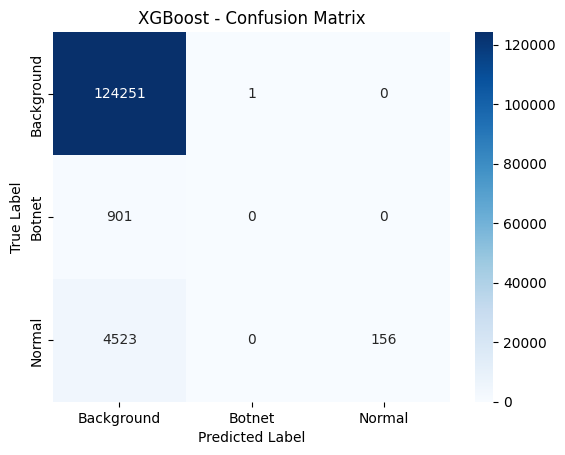


Classification Report:
 Background: Precision=0.96, Recall=1.00, F1-Score=0.98, Support=124252
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=901
 Normal: Precision=1.00, Recall=0.03, F1-Score=0.06, Support=4679

 Macro Avg:
 Precision=0.65, Recall=0.34, F1-Score=0.35
--------------------------------------------------

=== Results for LightGBM ===
F1 Score (Macro Average): 0.3552

Confusion Matrix:


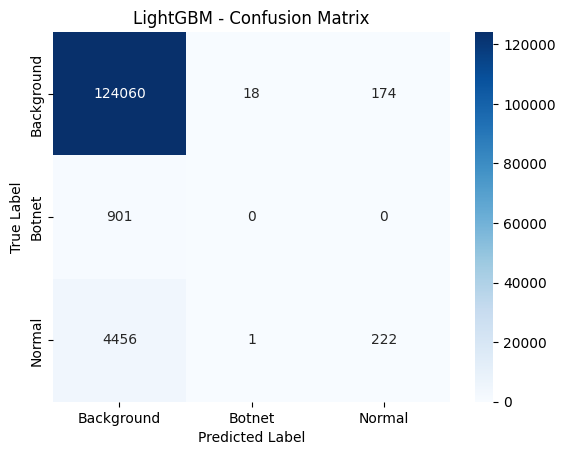


Classification Report:
 Background: Precision=0.96, Recall=1.00, F1-Score=0.98, Support=124252
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=901
 Normal: Precision=0.56, Recall=0.05, F1-Score=0.09, Support=4679

 Macro Avg:
 Precision=0.51, Recall=0.35, F1-Score=0.36
--------------------------------------------------

--- Testing on datasets/scenario6.binetflow ---

=== Results for Random Forest ===
F1 Score (Macro Average): 0.4015

Confusion Matrix:


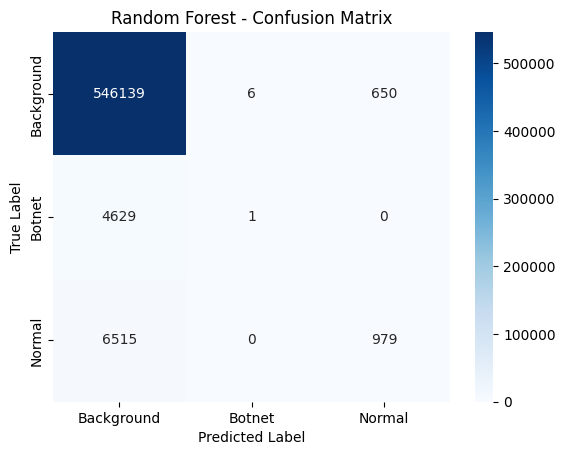


Classification Report:
 Background: Precision=0.98, Recall=1.00, F1-Score=0.99, Support=546795
 Botnet: Precision=0.14, Recall=0.00, F1-Score=0.00, Support=4630
 Normal: Precision=0.60, Recall=0.13, F1-Score=0.21, Support=7494

 Macro Avg:
 Precision=0.57, Recall=0.38, F1-Score=0.40
--------------------------------------------------

=== Results for XGBoost ===
F1 Score (Macro Average): 0.3783

Confusion Matrix:


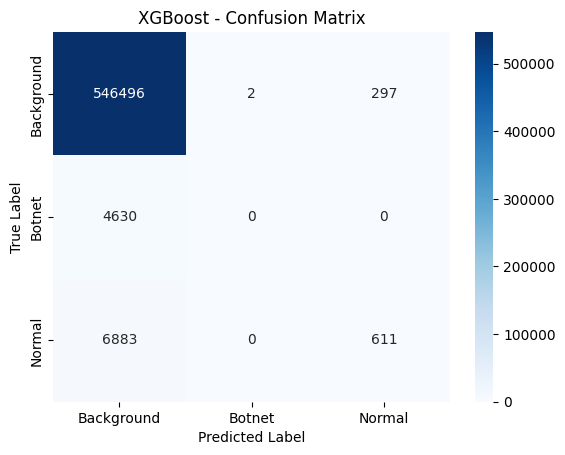


Classification Report:
 Background: Precision=0.98, Recall=1.00, F1-Score=0.99, Support=546795
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=4630
 Normal: Precision=0.67, Recall=0.08, F1-Score=0.15, Support=7494

 Macro Avg:
 Precision=0.55, Recall=0.36, F1-Score=0.38
--------------------------------------------------

=== Results for LightGBM ===
F1 Score (Macro Average): 0.3930

Confusion Matrix:


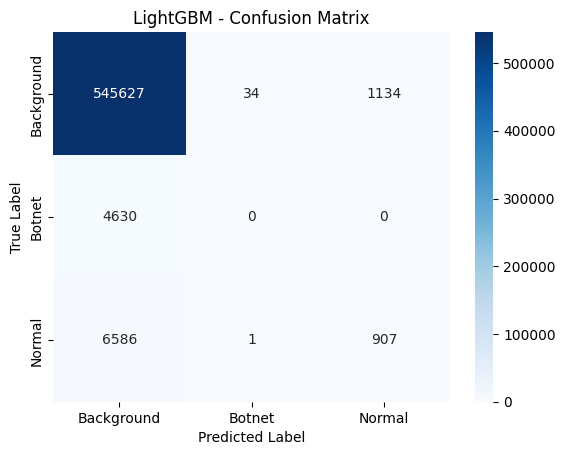


Classification Report:
 Background: Precision=0.98, Recall=1.00, F1-Score=0.99, Support=546795
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=4630
 Normal: Precision=0.44, Recall=0.12, F1-Score=0.19, Support=7494

 Macro Avg:
 Precision=0.47, Recall=0.37, F1-Score=0.39
--------------------------------------------------

--- Testing on datasets/scenario7.binetflow ---

=== Results for Random Forest ===
F1 Score (Macro Average): 0.3843

Confusion Matrix:


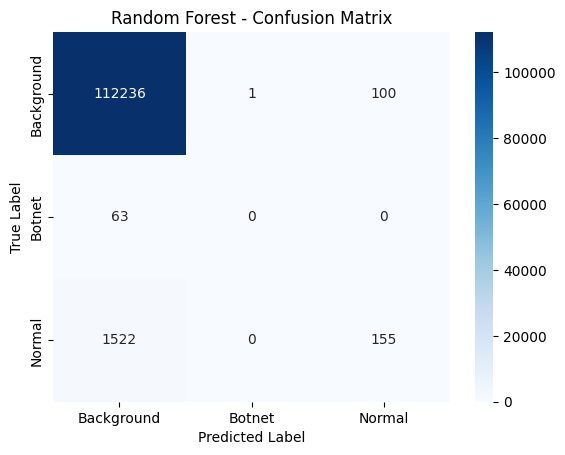


Classification Report:
 Background: Precision=0.99, Recall=1.00, F1-Score=0.99, Support=112337
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=63
 Normal: Precision=0.61, Recall=0.09, F1-Score=0.16, Support=1677

 Macro Avg:
 Precision=0.53, Recall=0.36, F1-Score=0.38
--------------------------------------------------

=== Results for XGBoost ===
F1 Score (Macro Average): 0.3677

Confusion Matrix:


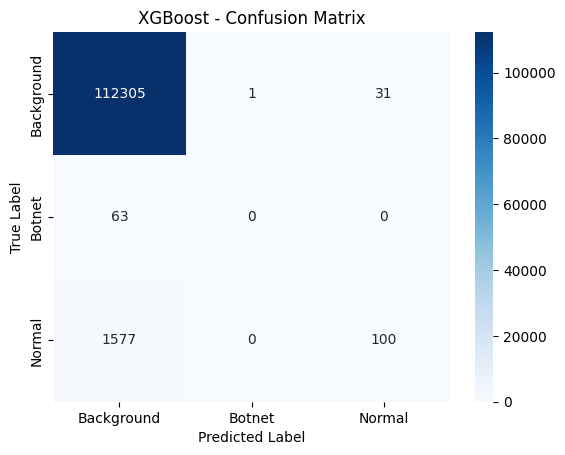


Classification Report:
 Background: Precision=0.99, Recall=1.00, F1-Score=0.99, Support=112337
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=63
 Normal: Precision=0.76, Recall=0.06, F1-Score=0.11, Support=1677

 Macro Avg:
 Precision=0.58, Recall=0.35, F1-Score=0.37
--------------------------------------------------

=== Results for LightGBM ===
F1 Score (Macro Average): 0.3793

Confusion Matrix:


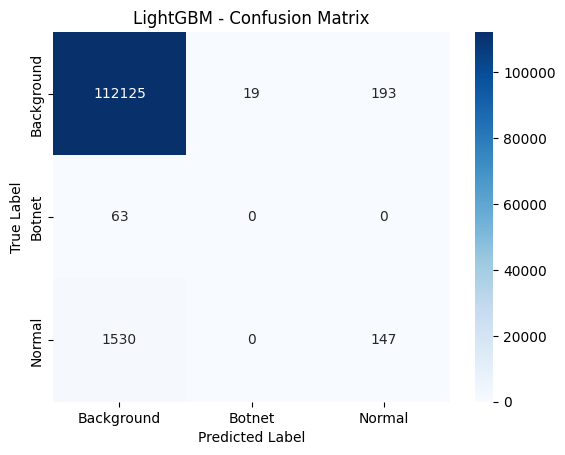


Classification Report:
 Background: Precision=0.99, Recall=1.00, F1-Score=0.99, Support=112337
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=63
 Normal: Precision=0.43, Recall=0.09, F1-Score=0.15, Support=1677

 Macro Avg:
 Precision=0.47, Recall=0.36, F1-Score=0.38
--------------------------------------------------

--- Testing on datasets/scenario8.binetflow ---

=== Results for Random Forest ===
F1 Score (Macro Average): 0.4188

Confusion Matrix:


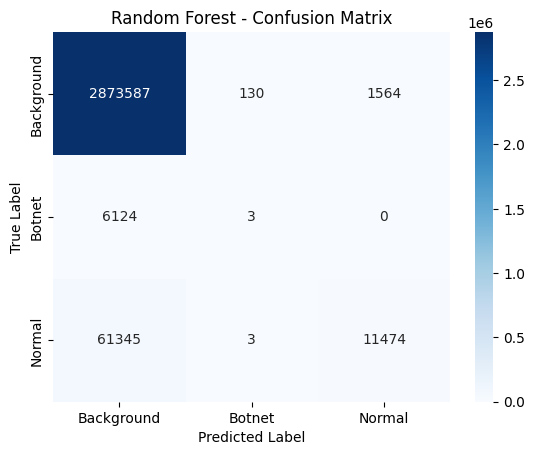


Classification Report:
 Background: Precision=0.98, Recall=1.00, F1-Score=0.99, Support=2875281
 Botnet: Precision=0.02, Recall=0.00, F1-Score=0.00, Support=6127
 Normal: Precision=0.88, Recall=0.16, F1-Score=0.27, Support=72822

 Macro Avg:
 Precision=0.63, Recall=0.39, F1-Score=0.42
--------------------------------------------------

=== Results for XGBoost ===
F1 Score (Macro Average): 0.3763

Confusion Matrix:


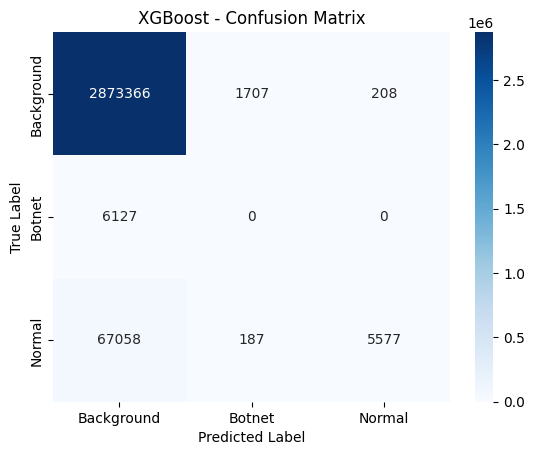


Classification Report:
 Background: Precision=0.98, Recall=1.00, F1-Score=0.99, Support=2875281
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=6127
 Normal: Precision=0.96, Recall=0.08, F1-Score=0.14, Support=72822

 Macro Avg:
 Precision=0.65, Recall=0.36, F1-Score=0.38
--------------------------------------------------

=== Results for LightGBM ===
F1 Score (Macro Average): 0.4703

Confusion Matrix:


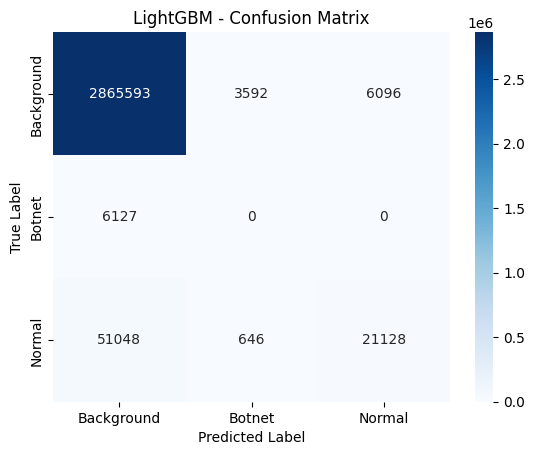


Classification Report:
 Background: Precision=0.98, Recall=1.00, F1-Score=0.99, Support=2875281
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=6127
 Normal: Precision=0.78, Recall=0.29, F1-Score=0.42, Support=72822

 Macro Avg:
 Precision=0.59, Recall=0.43, F1-Score=0.47
--------------------------------------------------

--- Testing on datasets/scenario9.binetflow ---

=== Results for Random Forest ===
F1 Score (Macro Average): 0.4260

Confusion Matrix:


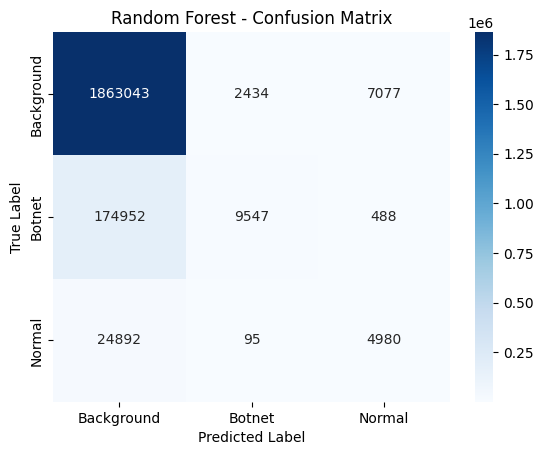


Classification Report:
 Background: Precision=0.90, Recall=0.99, F1-Score=0.95, Support=1872554
 Botnet: Precision=0.79, Recall=0.05, F1-Score=0.10, Support=184987
 Normal: Precision=0.40, Recall=0.17, F1-Score=0.23, Support=29967

 Macro Avg:
 Precision=0.70, Recall=0.40, F1-Score=0.43
--------------------------------------------------

=== Results for XGBoost ===
F1 Score (Macro Average): 0.4324

Confusion Matrix:


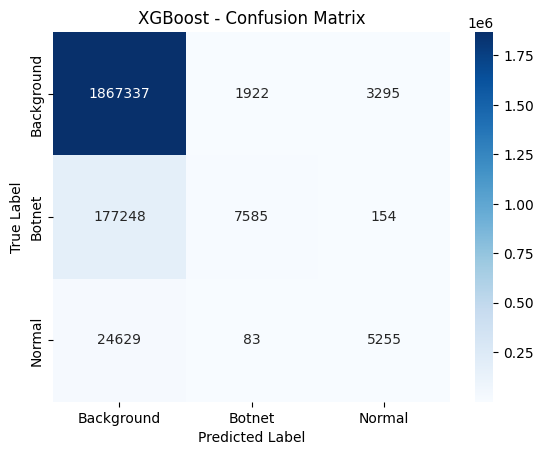


Classification Report:
 Background: Precision=0.90, Recall=1.00, F1-Score=0.95, Support=1872554
 Botnet: Precision=0.79, Recall=0.04, F1-Score=0.08, Support=184987
 Normal: Precision=0.60, Recall=0.18, F1-Score=0.27, Support=29967

 Macro Avg:
 Precision=0.77, Recall=0.40, F1-Score=0.43
--------------------------------------------------

=== Results for LightGBM ===
F1 Score (Macro Average): 0.4252

Confusion Matrix:


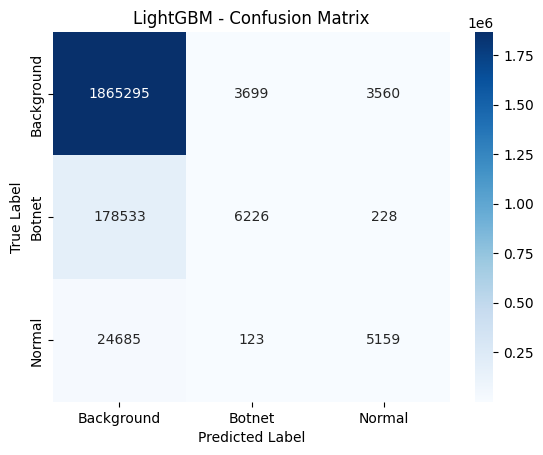


Classification Report:
 Background: Precision=0.90, Recall=1.00, F1-Score=0.95, Support=1872554
 Botnet: Precision=0.62, Recall=0.03, F1-Score=0.06, Support=184987
 Normal: Precision=0.58, Recall=0.17, F1-Score=0.27, Support=29967

 Macro Avg:
 Precision=0.70, Recall=0.40, F1-Score=0.43
--------------------------------------------------

--- Testing on datasets/scenario10.binetflow ---

=== Results for Random Forest ===
F1 Score (Macro Average): 0.3175

Confusion Matrix:


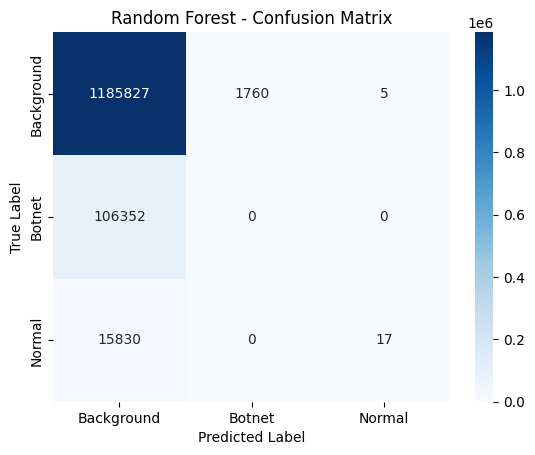


Classification Report:
 Background: Precision=0.91, Recall=1.00, F1-Score=0.95, Support=1187592
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=106352
 Normal: Precision=0.77, Recall=0.00, F1-Score=0.00, Support=15847

 Macro Avg:
 Precision=0.56, Recall=0.33, F1-Score=0.32
--------------------------------------------------

=== Results for XGBoost ===
F1 Score (Macro Average): 0.3386

Confusion Matrix:


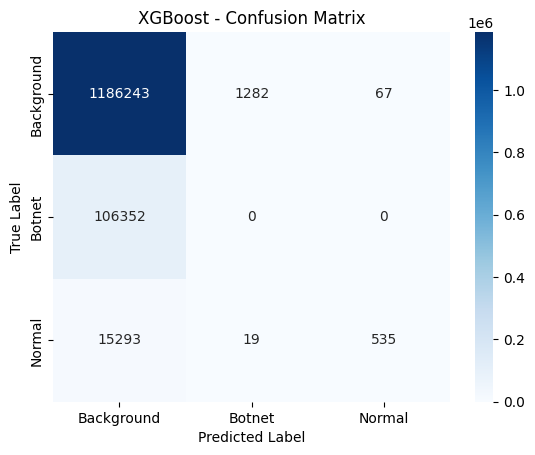


Classification Report:
 Background: Precision=0.91, Recall=1.00, F1-Score=0.95, Support=1187592
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=106352
 Normal: Precision=0.89, Recall=0.03, F1-Score=0.07, Support=15847

 Macro Avg:
 Precision=0.60, Recall=0.34, F1-Score=0.34
--------------------------------------------------

=== Results for LightGBM ===
F1 Score (Macro Average): 0.4493

Confusion Matrix:


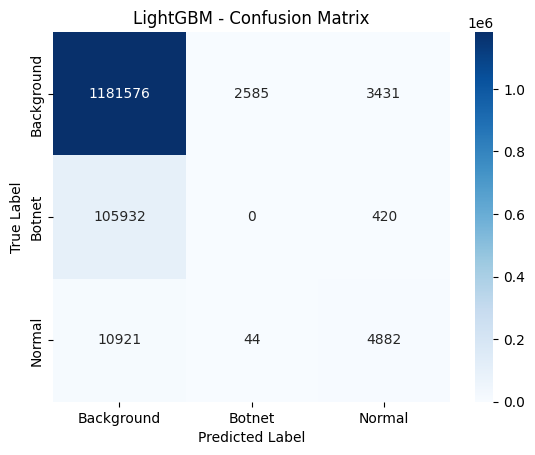


Classification Report:
 Background: Precision=0.91, Recall=0.99, F1-Score=0.95, Support=1187592
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=106352
 Normal: Precision=0.56, Recall=0.31, F1-Score=0.40, Support=15847

 Macro Avg:
 Precision=0.49, Recall=0.43, F1-Score=0.45
--------------------------------------------------

--- Testing on datasets/scenario11.binetflow ---

=== Results for Random Forest ===
F1 Score (Macro Average): 0.3422

Confusion Matrix:


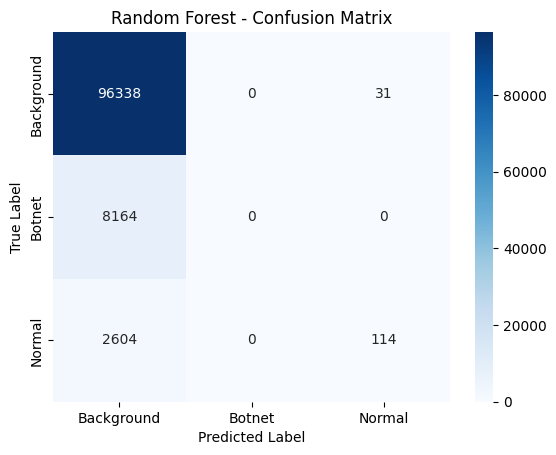


Classification Report:
 Background: Precision=0.90, Recall=1.00, F1-Score=0.95, Support=96369
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=8164
 Normal: Precision=0.79, Recall=0.04, F1-Score=0.08, Support=2718

 Macro Avg:
 Precision=0.56, Recall=0.35, F1-Score=0.34
--------------------------------------------------

=== Results for XGBoost ===
F1 Score (Macro Average): 0.3356

Confusion Matrix:


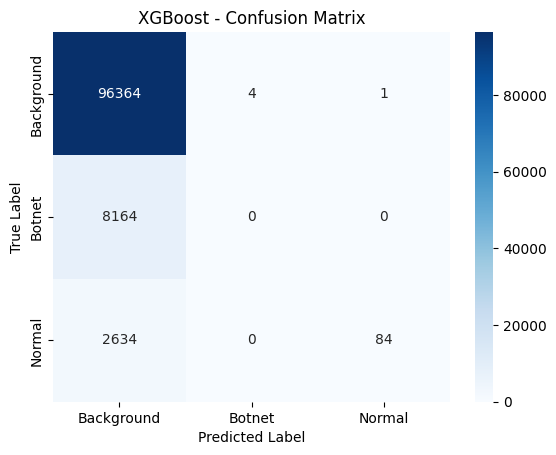


Classification Report:
 Background: Precision=0.90, Recall=1.00, F1-Score=0.95, Support=96369
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=8164
 Normal: Precision=0.99, Recall=0.03, F1-Score=0.06, Support=2718

 Macro Avg:
 Precision=0.63, Recall=0.34, F1-Score=0.34
--------------------------------------------------

=== Results for LightGBM ===
F1 Score (Macro Average): 0.4452

Confusion Matrix:


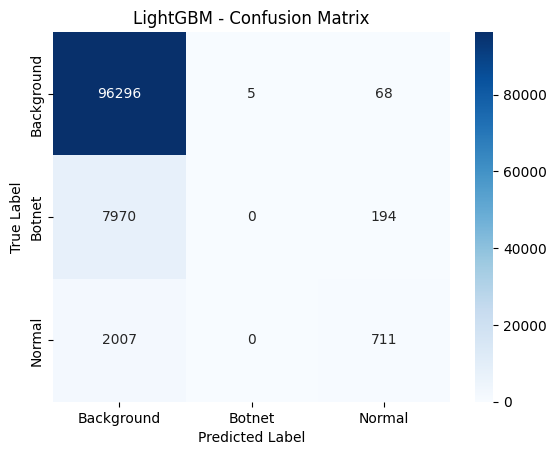


Classification Report:
 Background: Precision=0.91, Recall=1.00, F1-Score=0.95, Support=96369
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=8164
 Normal: Precision=0.73, Recall=0.26, F1-Score=0.39, Support=2718

 Macro Avg:
 Precision=0.55, Recall=0.42, F1-Score=0.45
--------------------------------------------------

--- Testing on datasets/scenario12.binetflow ---

=== Results for Random Forest ===
F1 Score (Macro Average): 0.3722

Confusion Matrix:


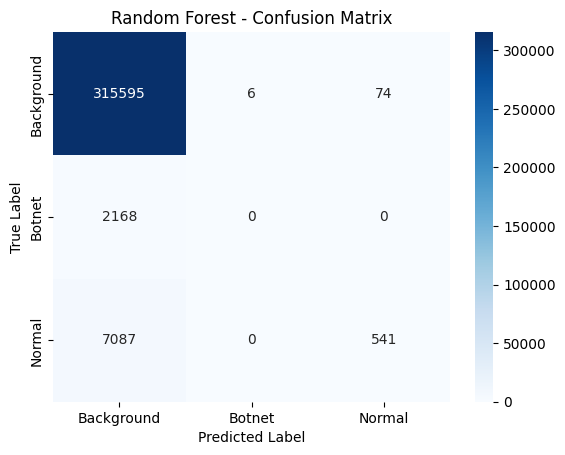


Classification Report:
 Background: Precision=0.97, Recall=1.00, F1-Score=0.99, Support=315675
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=2168
 Normal: Precision=0.88, Recall=0.07, F1-Score=0.13, Support=7628

 Macro Avg:
 Precision=0.62, Recall=0.36, F1-Score=0.37
--------------------------------------------------

=== Results for XGBoost ===
F1 Score (Macro Average): 0.3561

Confusion Matrix:


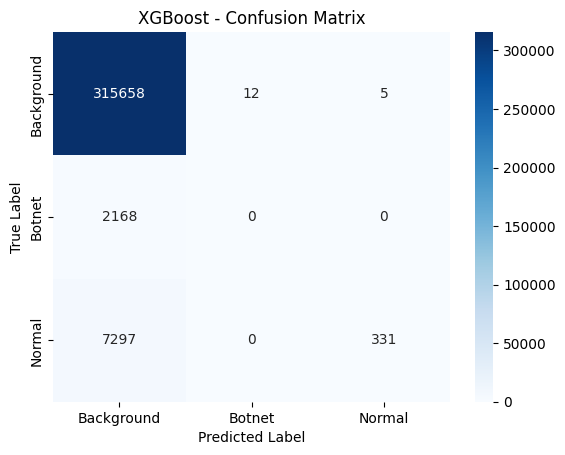


Classification Report:
 Background: Precision=0.97, Recall=1.00, F1-Score=0.99, Support=315675
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=2168
 Normal: Precision=0.99, Recall=0.04, F1-Score=0.08, Support=7628

 Macro Avg:
 Precision=0.65, Recall=0.35, F1-Score=0.36
--------------------------------------------------

=== Results for LightGBM ===
F1 Score (Macro Average): 0.3694

Confusion Matrix:


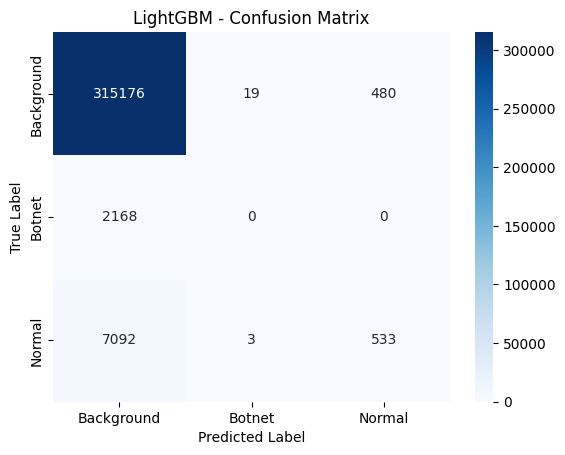


Classification Report:
 Background: Precision=0.97, Recall=1.00, F1-Score=0.98, Support=315675
 Botnet: Precision=0.00, Recall=0.00, F1-Score=0.00, Support=2168
 Normal: Precision=0.53, Recall=0.07, F1-Score=0.12, Support=7628

 Macro Avg:
 Precision=0.50, Recall=0.36, F1-Score=0.37
--------------------------------------------------

--- Testing on datasets/scenario13.binetflow ---

=== Results for Random Forest ===
F1 Score (Macro Average): 0.4856

Confusion Matrix:


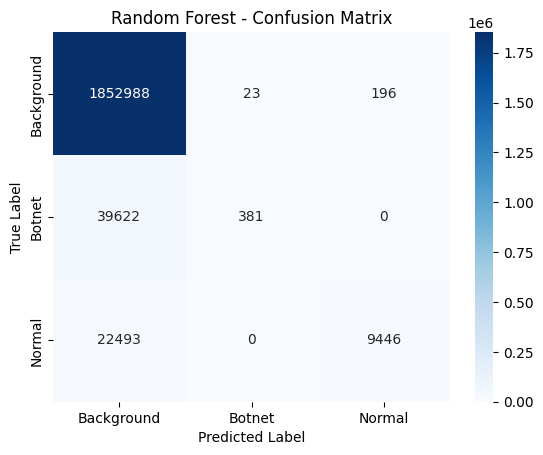


Classification Report:
 Background: Precision=0.97, Recall=1.00, F1-Score=0.98, Support=1853207
 Botnet: Precision=0.94, Recall=0.01, F1-Score=0.02, Support=40003
 Normal: Precision=0.98, Recall=0.30, F1-Score=0.45, Support=31939

 Macro Avg:
 Precision=0.96, Recall=0.44, F1-Score=0.49
--------------------------------------------------

=== Results for XGBoost ===
F1 Score (Macro Average): 0.4957

Confusion Matrix:


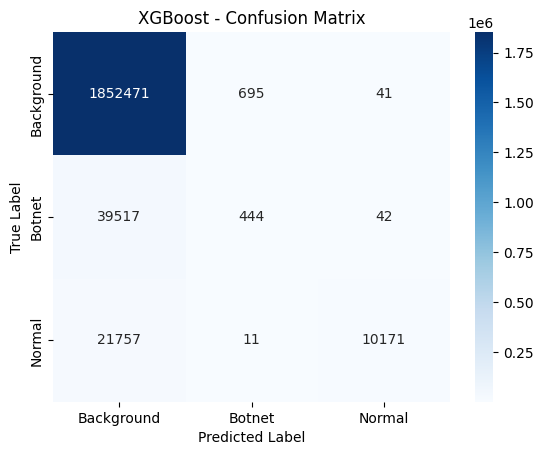


Classification Report:
 Background: Precision=0.97, Recall=1.00, F1-Score=0.98, Support=1853207
 Botnet: Precision=0.39, Recall=0.01, F1-Score=0.02, Support=40003
 Normal: Precision=0.99, Recall=0.32, F1-Score=0.48, Support=31939

 Macro Avg:
 Precision=0.78, Recall=0.44, F1-Score=0.50
--------------------------------------------------

=== Results for LightGBM ===
F1 Score (Macro Average): 0.5938

Confusion Matrix:


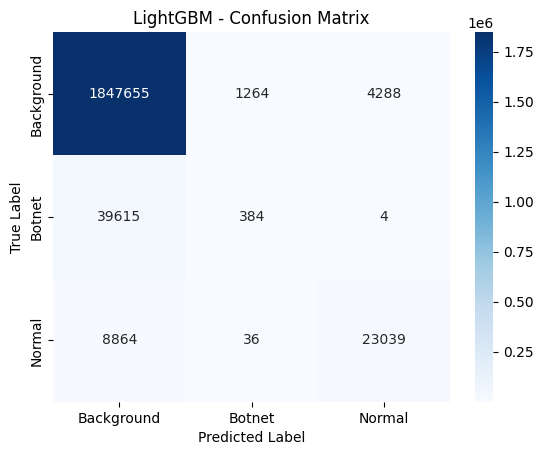


Classification Report:
 Background: Precision=0.97, Recall=1.00, F1-Score=0.99, Support=1853207
 Botnet: Precision=0.23, Recall=0.01, F1-Score=0.02, Support=40003
 Normal: Precision=0.84, Recall=0.72, F1-Score=0.78, Support=31939

 Macro Avg:
 Precision=0.68, Recall=0.58, F1-Score=0.59
--------------------------------------------------


In [24]:
scenarios = [
    'datasets/scenario1.binetflow',
    'datasets/scenario2.binetflow',
    'datasets/scenario3.binetflow',
    'datasets/scenario4.binetflow',
    'datasets/scenario5.binetflow',
    'datasets/scenario6.binetflow',
    'datasets/scenario7.binetflow',
    'datasets/scenario8.binetflow',
    'datasets/scenario9.binetflow',
    'datasets/scenario10.binetflow',
    'datasets/scenario11.binetflow',
    'datasets/scenario12.binetflow',
    'datasets/scenario13.binetflow'
]

models = {
    'Random Forest': rf,
    'XGBoost': xgb,
    'LightGBM': lgbm
}

results = {}

# Loop to test each scenario
for scenario in scenarios:
    X_test, y_test = load_and_process(scenario)

    print(f"\n--- Testing on {scenario} ---")
    
    # Loop to test each model
    for model, name in zip([rf, xgb, lgbm], ["Random Forest", "XGBoost", "LightGBM"]):
        preds = model.predict(X_test)
        f1 = f1_score(y_test, preds, average='macro', zero_division=0)
        cm = confusion_matrix(y_test, preds)
        report = classification_report(y_test, preds, target_names=['Background', 'Botnet', 'Normal'], output_dict=True, zero_division=0)



        results[name] = {
        'model': model,
        'f1_macro': f1,
        'confusion_matrix': cm,
        'report': report
    }
        
    # Loop to print the results of each model
    for model_name, metrics in results.items():
        print(f"\n=== Results for {model_name} ===")
        print(f"F1 Score (Macro Average): {metrics['f1_macro']:.4f}\n")
        
        print("Confusion Matrix:")
        sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Background', 'Botnet', 'Normal'],
            yticklabels=['Background', 'Botnet', 'Normal'])
        plt.title(f"{model_name} - Confusion Matrix")
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()
        #print(metrics['confusion_matrix'])
        print("\nClassification Report:")
        report = metrics['report']



        # Print per class precision, recall, f1
        for class_name in ['Background', 'Botnet', 'Normal']:
            precision = report[class_name]['precision']
            recall = report[class_name]['recall']
            f1 = report[class_name]['f1-score']
            support = report[class_name]['support']
            print(f" {class_name}: Precision={precision:.2f}, Recall={recall:.2f}, F1-Score={f1:.2f}, Support={int(support)}")
        
        # Print macro average
        print("\n Macro Avg:")
        macro = report['macro avg']
        print(f" Precision={macro['precision']:.2f}, Recall={macro['recall']:.2f}, F1-Score={macro['f1-score']:.2f}")

        print("-" * 50)

